<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/Regression_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chuẩn bị dữ liệu và Khởi tạo Mô hình**

In [4]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Tạo dữ liệu giả lập cho bài toán giá nhà
np.random.seed(42)
n_samples = 1000

# Tạo các đặc trưng (Features)
dien_tich = np.random.uniform(30, 150, n_samples)      # 30m2 đến 150m2
so_phong = np.random.randint(1, 5, n_samples)         # 1 đến 4 phòng
khoang_cach = np.random.uniform(1, 20, n_samples)     # 1km đến 20km đến trung tâm

# Tạo nhãn (Target - Giá nhà thực tế dựa trên công thức có sẵn + nhiễu)
# Giá nhà = dien_tich * 15 + so_phong * 50 - khoang_cach * 5 + nhiễu
gia_nha = (dien_tich * 15) + (so_phong * 50) - (khoang_cach * 5) + np.random.normal(0, 25, n_samples)

# Chuyển thành DataFrame để dễ quản lý
df = pd.DataFrame({
    'DienTich': dien_tich,
    'SoPhong': so_phong,
    'KhoangCach': khoang_cach,
    'GiaNha': gia_nha
})


X = df[['DienTich', 'SoPhong', 'KhoangCach']].values
y = df['GiaNha'].values

# Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Feature Scaling) - Rất quan trọng đối với Deep Learning
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = Sequential([
    # Layer đầu vào nhận 3 đặc trưng, đi qua lớp Dense 64 Node với hàm kích hoạt ReLU
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    # Lớp ẩn thứ hai với 32 Node
    layers.Dense(32, activation='relu'),
    # Lớp đầu ra (Output layer): Vì là bài toán hồi quy (Regression) dự đoán 1 giá trị liên tục,
    # nên lớp cuối cùng CHỈ CÓ 1 NODE và KHÔNG DÙNG hàm kích hoạt (activation=None).
    layers.Dense(1)
])

# Biên dịch mô hình: Sử dụng Optimizer 'Adam' và hàm mất mát là MSE (Mean Squared Error)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='mse',
              metrics=['mae']) # Theo dõi thêm chỉ số MAE (Mean Absolute Error)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

**Huấn luyện Mô hình**

In [5]:

history = model.fit(X_train_scaled, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 2253498.7500 - mae: 1404.7058 - val_loss: 2184081.5000 - val_mae: 1381.4840
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2034378.0000 - mae: 1329.1239 - val_loss: 1695216.3750 - val_mae: 1211.4216
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1220711.0000 - mae: 1015.1116 - val_loss: 521988.4062 - val_mae: 664.7342
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 192318.2031 - mae: 350.6392 - val_loss: 53425.1797 - val_mae: 185.7940
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 46879.7266 - mae: 176.0954 - val_loss: 21064.1465 - val_mae: 113.5329
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 25550.9277 - mae: 129.1123 - val_loss: 18097.1191 - val_mae: 105.5005
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 21500.2461 - mae: 119.1592 - val_loss: 16413.5195 - val_mae: 101.1327
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 18758.8496 - 

**Đánh giá và Trực quan hóa Kết quả**

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


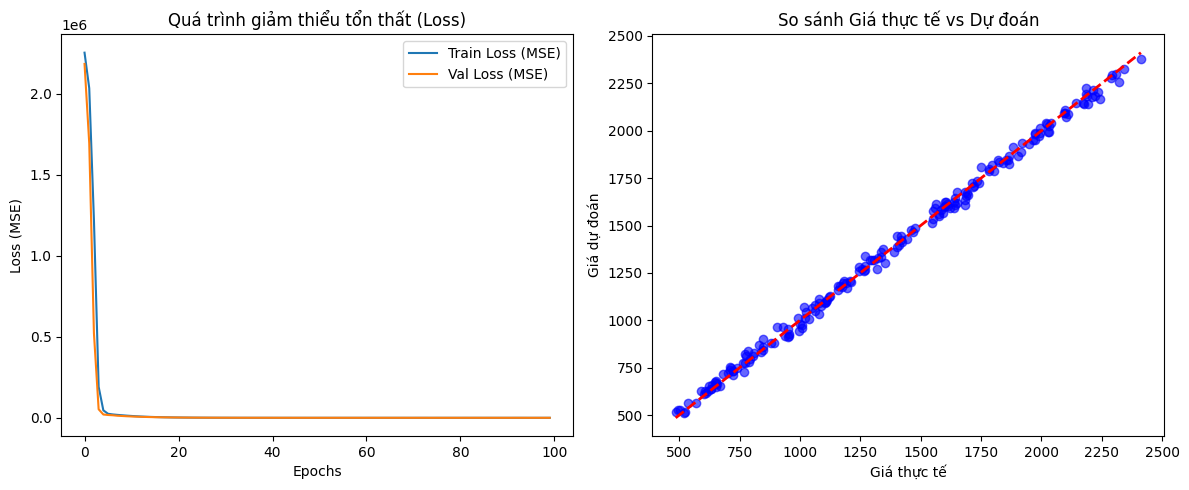

----------------------------------------
Sai số tuyệt đối trung bình (MAE) trên tập Test: 21.12 (triệu đồng)
----------------------------------------


In [6]:

# Vẽ biểu đồ Loss qua các Epochs để kiểm tra Overfitting/Underfitting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Quá trình giảm thiểu tổn thất (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# Dự đoán thử trên tập Test
y_pred = model.predict(X_test_scaled).flatten()

# Vẽ biểu đồ so sánh Giá thực tế vs Giá dự đoán
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('So sánh Giá thực tế vs Dự đoán')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')

plt.tight_layout()
plt.show()

# Đánh giá sai số trung bình (MAE) trên tập Test
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(fontfont := "-"*40)
print(f"Sai số tuyệt đối trung bình (MAE) trên tập Test: {test_mae:.2f} (triệu đồng)")
print(fontfont)